<a href="https://colab.research.google.com/github/Livianita/Laboratorio_Algebra_Lineal/blob/main/Lab3_Optimiza_TesteoLivia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización de datos para la clasificación

# Explorando MNIST(modified National Institute of Standars and Technology dataset) y redes neuronales

El propósito de este documento es entender sobre redes neuronales y como varía su desempeño al utilizar diferentes optimizadores.

Antes de poder construir redes neuronales, necesitamos importar algunas cosas de Keras (datos de Internet) y preparar nuestros datos. El siguiente código extrae el conjunto de datos correspondientes a MNIST, proporcionado por Keras. Además, modifica las etiquetas de un valor numérico 0-9 a un vector one-hot encoded.

One-hot encoding hace referencia a un grupo de bits entre los cuales las combinaciones validas de valores son solo aquellas con un solo bit alto (1) y todas las demás bajas (0). Mirar la gráfica siguiente:
<center><img src="https://i.imgur.com/wKtY1Og.png" alt="drawing" width="400"/>

# Importación de Datos

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


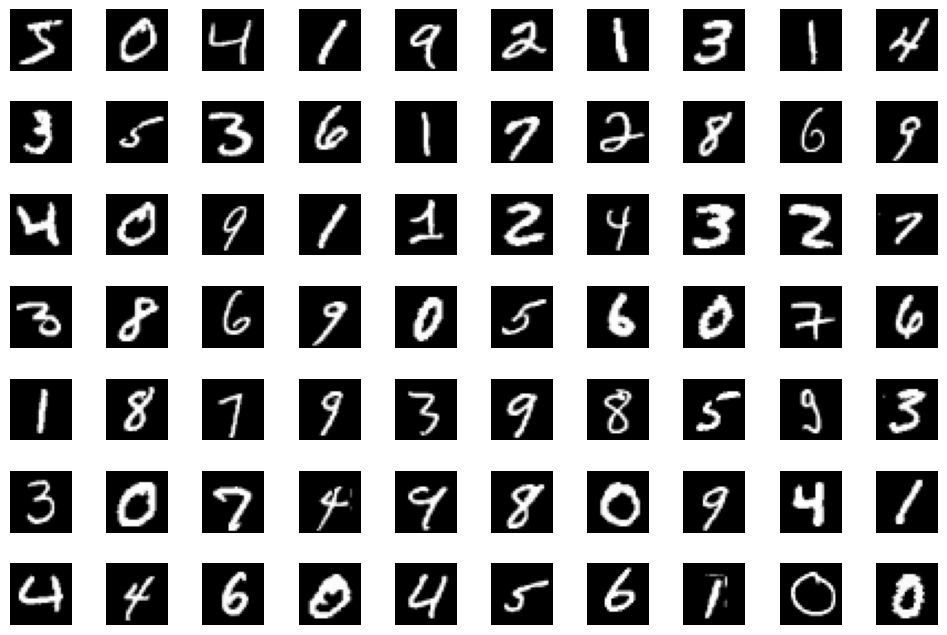

In [1]:
# @title
import matplotlib.pyplot as plt
import tensorflow as tf

# Load only the images (X_show) from the MNIST dataset
(X_show, _), _ = tf.keras.datasets.mnist.load_data()

# Plot a 10x7 grid of digit images
fig, axes = plt.subplots(7, 10, figsize=(12, 8))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_show[i], cmap='gray')  # Display image in grayscale
    ax.axis('off')  # Hide axis
    # Removed the label display since y_train is not used
    # If you'd like to show indices instead, you can uncomment the next line:
    # ax.set_title(f'#{i}', fontsize=12)

plt.show()

# Instalación de TensorFlow

In [2]:
# @title
!pip install tensorflow


# Comparación de Optimizadores. Gráficas de  Loss/Accuracy vs. Epochs (ACTIVIDAD BASE)

Training with Gradient Descent (GD)...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Stochastic GD (SGD)...
Training with Mini-Batch SGD...
Training with Momentum SGD...
Training with Adam...
Training with RMSprop...
Training with RMSprop + Momentum...


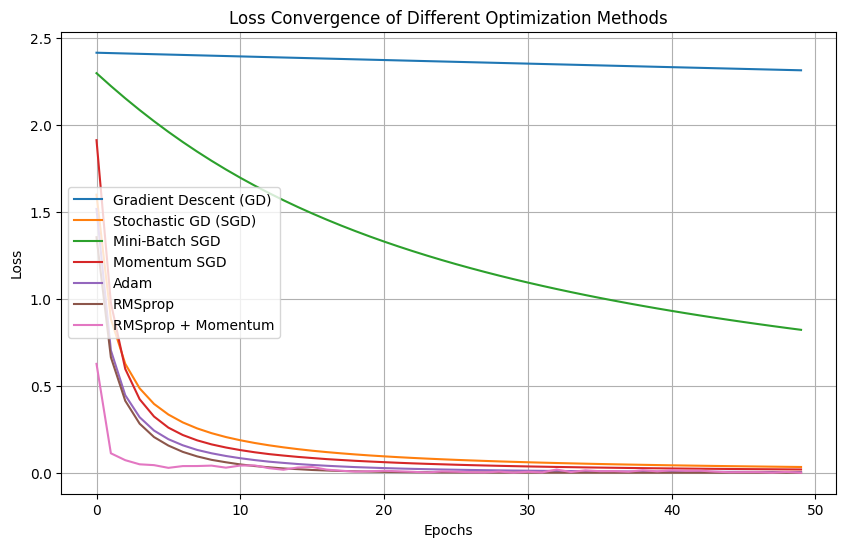

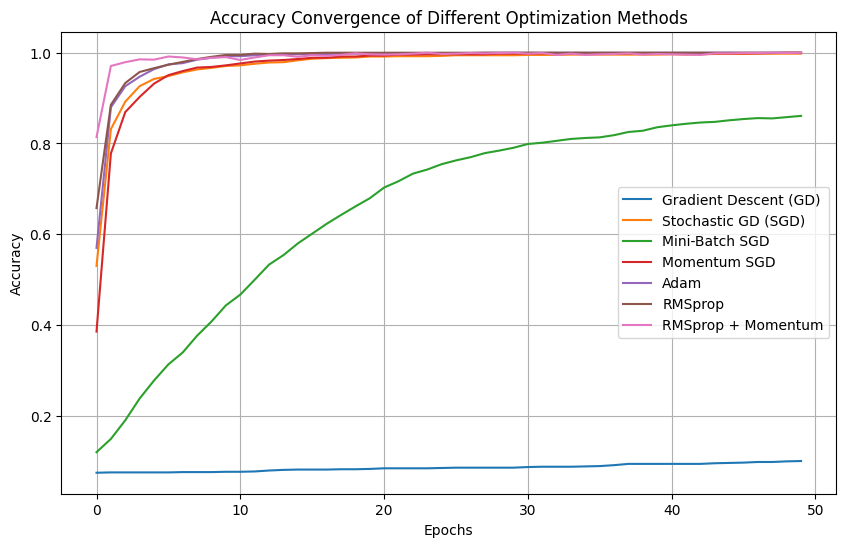

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

  # ---- Load and Preprocess Data ----
digits = load_digits()   # formato original-> (1797, 8, 8)
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features, i.e., (1797, 64) ->  1797 samples con 64 features
y = digits.target.reshape(-1, 1)  # Labels, Convierte el vector de etiquetas de (1797,) a una matriz columna (1797, 1).

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)  # se usa zscore para normalizar los datos de entrada

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)  #False, formato de matriz densa tal como muestra la figura al comienzo del script

y = encoder.fit_transform(y)  # generamos las clases e.g.,   Clase 3 [0,0,0,1]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="tanh"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer  (64 porque esas son el numero de features)
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (una por cada clase de dígito: 0-9, total 10 clases).
    ])
    return model

# ---- Set Learning Rate and Hyperparameters ----
learning_rate = 0.001  #
momentum_beta = 0.98  #
adam_beta1 = 0.9  #
adam_beta2 = 0.999  #
RMSprop_beta2=0.9

# ---- Define Optimizers with Modifiable beta1 and beta2 ----   AQUI VER COMO SE USA CADA DIFERENTE OPTIMIZADOR PARA LAS ACTIVIDADES POSTERIORES
optimizers = {
      "Gradient Descent (GD)": tf.keras.optimizers.SGD(learning_rate=learning_rate),
    "Stochastic GD (SGD)": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0),
    "Mini-Batch SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0),
    "Momentum SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum_beta),
    "Adam": tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=adam_beta1, beta_2=adam_beta2),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=learning_rate, rho=0.9),
          "RMSprop + Momentum": tf.keras.optimizers.RMSprop(learning_rate=learning_rate, rho=RMSprop_beta2, momentum=momentum_beta)

}

# Definir los batch sizes para cada optimizador
batch_sizes = {
    "Gradient Descent (GD)": X_train.shape[0],  # Usa TODAS las muestras por iteración (GD)
    "Stochastic GD (SGD)": 1,  # Usa 1 muestra por iteración
    "Mini-Batch SGD": 32,  # Usa Mini-Batches de 32 muestras
    "Momentum SGD": 32,  # Igual que Mini-Batch, pero con memoria del gradiente
    "Adam": 32,  # Adam generalmente usa Mini-Batch
    "RMSprop": 32,  # RMSprop generalmente usa Mini-Batch
    "RMSprop + Momentum": 32,  # RMSprop generalmente usa Mini-Batch
}

# ---- Train Model with Each Optimizer ----
history_loss = {}
history_acc = {}

for name, optimizer in optimizers.items():
    print(f"Training with {name}...")
    model = build_model(activation="tanh")  # MODIFY ACTIVATION FUNCTION!
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(X_train, y_train, epochs=50, batch_size=batch_sizes[name], verbose=0, validation_data=(X_test, y_test))

    history_loss[name] = history.history["loss"]
    history_acc[name] = history.history["accuracy"]

# ---- Plot Loss Convergence ----
plt.figure(figsize=(10, 6))
for name, loss in history_loss.items():
    plt.plot(loss, label=name)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Convergence of Different Optimization Methods")
plt.legend()
plt.grid()
plt.show()

# ---- Plot Accuracy Convergence ----
plt.figure(figsize=(10, 6))                                               #1 Base
for name, acc in history_acc.items():                                     #2 Base
    plt.plot(acc, label=name)                                             #3 Base

plt.xlabel("Epochs")                                                      #4 Base
plt.ylabel("Accuracy")                                                    #5 Base
plt.title("Accuracy Convergence of Different Optimization Methods")       #6 Base
plt.legend()                                                              #7 Base
plt.grid()                                                                #8 Base
plt.show()                                                                #9 Base


# **Actividades**

# 1. Modificar la Tasa de Aprendizaje (`learning rate`)

#Probar con valores con 0.001, 0.05, 0.1 en los optimizadores Adam y en el Momentum GD:  Graficar  Loss vs. Epochs

¿Cómo afecta una tasa de aprendizaje alta a la convergencia en cada enfoque ?

Livia: De las grficas se observa que para lastasas mas altas, es decir, 0.1, ambos optimizadores no convergen. Adam ha pesar de que puede ajustar de manera adaptativa al  menos con es rt de 0.999 no funciona, tal vez probado con otro valor. El Momentum SGD a psar que por definicion debe reducir oscilaciones para ese valor de 0.9 no resulta util con esat tasa de aprendizaje 0.1.

¿Qué sucede si la tasa de aprendizaje es demasiado baja en cada enfoque?

Livia: Para una tasa Baja, 0.001 el Adam responde bien, en pocas epocas ya converge.  Para el momentum SGD arranca con un valor mayor al de arranque de ADAM y converge a mas de 50 epocas.

¿Cuál/cuales tasa/s de aprendizaje ofrece un mejor desempeño en cada enfoque?

Livia: El ADAM convege mejor con la tasa mas baja usada. El Momentum SGD lo hace con la intermedia de 0.05

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Adam con learning rate = 0.001
Entrenando Momentum SGD con learning rate = 0.001
Entrenando Adam con learning rate = 0.05
Entrenando Momentum SGD con learning rate = 0.05
Entrenando Adam con learning rate = 0.1
Entrenando Momentum SGD con learning rate = 0.1
Entrenamiento terminado.


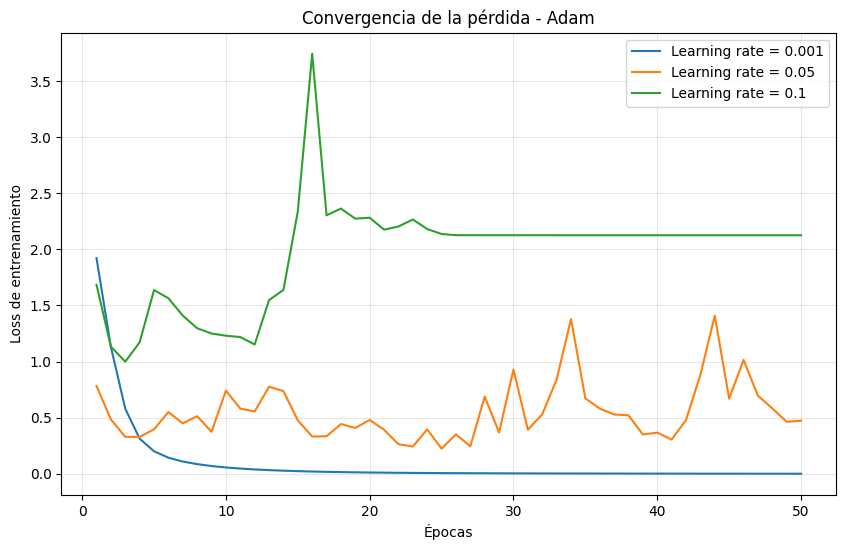

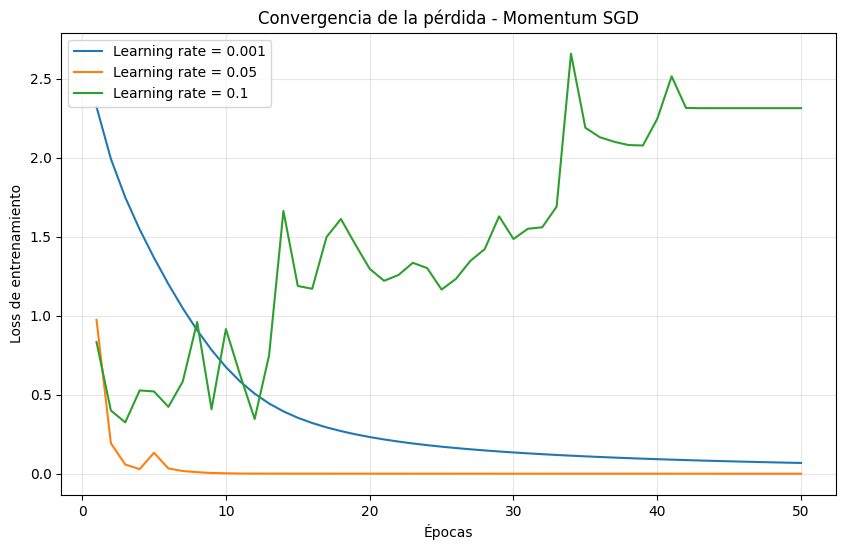

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
learning_rates = [0.001, 0.05, 0.1]  # Vector of learning rates
momentum_beta1 = 0.9
batch_size=32
adam_beta1 = 0.9
adam_beta2 = 0.999


# ---- Train Model with Each Learning Rate ----
history_loss_adam = {}
history_loss_Momentum = {}

for lr in learning_rates:
    # Entrenar con Adam
    tf.keras.utils.set_random_seed(42)
    model_adam = build_model(activation="relu")

    optimizer_adam = tf.keras.optimizers.Adam(
        learning_rate=lr,
        beta_1=adam_beta1,
        beta_2=adam_beta2
    )

    model_adam.compile(
        optimizer=optimizer_adam,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"Entrenando Adam con learning rate = {lr}")

    history_adam = model_adam.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    history_loss_adam[lr] = history_adam.history["loss"]

    # Entrenar con Momentum SGD
    tf.keras.utils.set_random_seed(42)

    model_momentum = build_model(activation="relu")

    optimizer_momentum = tf.keras.optimizers.SGD(
        learning_rate=lr,
        momentum=momentum_beta1
    )

    model_momentum.compile(
        optimizer=optimizer_momentum,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"Entrenando Momentum SGD con learning rate = {lr}")

    history_momentum = model_momentum.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    history_loss_Momentum[lr] = history_momentum.history["loss"]

print("Entrenamiento terminado.")


#inserte aqui los códigos para el plot
# ---- Plot Loss Convergence Adam ----

plt.figure(figsize=(10, 6))

for lr, loss in history_loss_adam.items():
    plt.plot(
        range(1, len(loss) + 1),
        loss,
        label=f"Learning rate = {lr}"
    )

plt.xlabel("Épocas")
plt.ylabel("Loss de entrenamiento")
plt.title("Convergencia de la pérdida - Adam")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# ---- Plot Loss Convergence Momentum SGD ----
plt.figure(figsize=(10, 6))

for lr, loss in history_loss_Momentum.items():
    plt.plot(
        range(1, len(loss) + 1),
        loss,
        label=f"Learning rate = {lr}"
    )

plt.xlabel("Épocas")
plt.ylabel("Loss de entrenamiento")
plt.title("Convergencia de la pérdida - Momentum SGD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



#2.  Experimentar con el Tamaño del Mini-Batch (`batch_size`) en el optimizador Adam:  Graficar  Loss vs. Epochs

 # Probar el `batch_size` con 16, 64, 128

¿Qué ocurre con la estabilidad (se refiere al ruido) del entrenamiento al usar batches más pequeños?

Livia: Con el batch de 16 redujo la pérdida comenzo ya desde valores mas bajos y su convergencia tambien es mas rapida. De lso tres es el mas rapido pero l hacer el batch mas peque;os estamos probando el modelo con mas data, tiende a comportarse similar al SGD más rápido pero mas ruidoso.

¿Qué tamaño de batch produce la mejor precisión en el conjunto de prueba?

Livia: En mi caso cuando el batch fue el mayor, es decir, 128 el accuracy fue mayor que con 16 o 64 batches. La diferencia no es lo sfientemente grande como para poder declar con todo soporte que es el modelo ganador.  La ventaja de esta batch 128 frente al de 16 es que el flujo de las predicciones sera mas suave,menos ruidoso.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando con batch size = 16...
Batch 16 → Accuracy de prueba: 97.50%

Entrenando con batch size = 64...
Batch 64 → Accuracy de prueba: 97.22%

Entrenando con batch size = 128...
Batch 128 → Accuracy de prueba: 98.06%



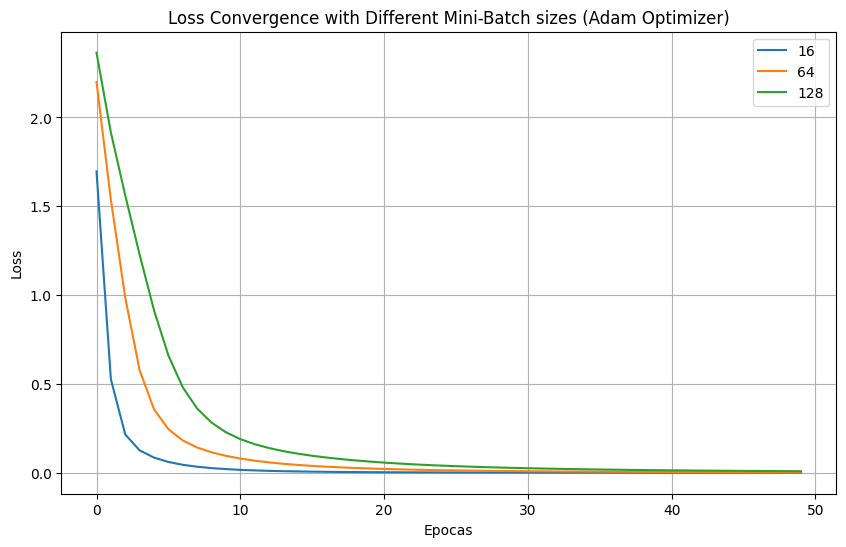

Resultados en el conjunto de prueba:

Batch size = 16: accuracy = 97.50%
Batch size = 64: accuracy = 97.22%
Batch size = 128: accuracy = 98.06%

Mejor(es) batch size: [128]
Mayor accuracy de prueba: 98.06%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(40, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
lr = 0.001 # learning rate
batch_size =  [16, 64, 128]  # Vector of mini-batch
momentum_beta1 = 0.9
adam_beta1 = 0.9
adam_beta2 = 0.999

# ---- Train Model with Each Learning Rate ----
history_loss_adam = {} # Initialize before the loop
test_accuracy_adam = {} # Initialize before the loop
#Inserta su código aqui

history_loss_adam = {}
test_accuracy_adam = {}

for bs in batch_size:
    tf.keras.utils.set_random_seed(42)

    model = build_model(activation="relu")

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr,
        beta_1=adam_beta1,
        beta_2=adam_beta2
    )

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"Entrenando con batch size = {bs}...")

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=bs,
        verbose=0
    )

    history_loss_adam[bs] = history.history["loss"]

    # Estas instrucciones están DENTRO del for
    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    test_accuracy_adam[bs] = test_accuracy

    print(f"Batch {bs} → Accuracy de prueba: {test_accuracy:.2%}\n")

# The following block is removed as history_acc is not defined in this context
# plt.figure(figsize=(10, 6))
# for name, acc in history_acc.items():
#     plt.plot(acc, label=name)

# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.title("Accuracy Convergence of Different Optimization Methods")
# plt.legend()
# plt.grid()
# plt.show()

# ---- Plot Loss Convergence Adam ----
plt.figure(figsize=(10, 6))
for lr, lossAdam in history_loss_adam.items():
    plt.plot(lossAdam, label=lr)

plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.title("Loss Convergence with Different Mini-Batch sizes (Adam Optimizer)")
plt.legend()
plt.grid()
plt.show()

#info adicional para analisis
print("Resultados en el conjunto de prueba:\n")

for bs, accuracy in test_accuracy_adam.items():
    print(f"Batch size = {bs}: accuracy = {accuracy:.2%}")

mejor_accuracy = max(test_accuracy_adam.values())

# Mostrar todos los tamaños ganadores si hay empate
mejores_batches = [
    bs
    for bs, accuracy in test_accuracy_adam.items()
    if np.isclose(accuracy, mejor_accuracy, rtol=0, atol=1e-8)
]

print(f"\nMejor(es) batch size: {mejores_batches}")
print(f"Mayor accuracy de prueba: {mejor_accuracy:.2%}")

#3. Comparar el Impacto del `Momentum` en SGD: Graficar Accuracy vs. Epochs

 # Probar valores de Momentum de 0.4, 0.75, 0.99

¿Cómo afecta un momentum alto la el accuracy?

Livia: Graficamos acuraccy contra epocas para diferentes momentums. m=0.4 se alcanza una precision de 100% en menos de 10 epocas. Ahora si subimos el m a 0.75 la precision de 100% se alcanza mucho mas rapido, menos de 5 epocas. y Para el momentum mas alto =0.9 junto con la tasa de aprendizaje de 0.1 se observa un problema. Inicialmente alcanza rapido una precicion del 90% a la par de cuando m=0.5, pero se desequilibra y cae profundamente hasta aprox un 10%. Entonces ese momemtum o velocidad rapida junto con un learning rate alto genero un desequilibrio en el aprendizaje.

Training with Momentum = 0.4...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Momentum = 0.75...
Training with Momentum = 0.99...


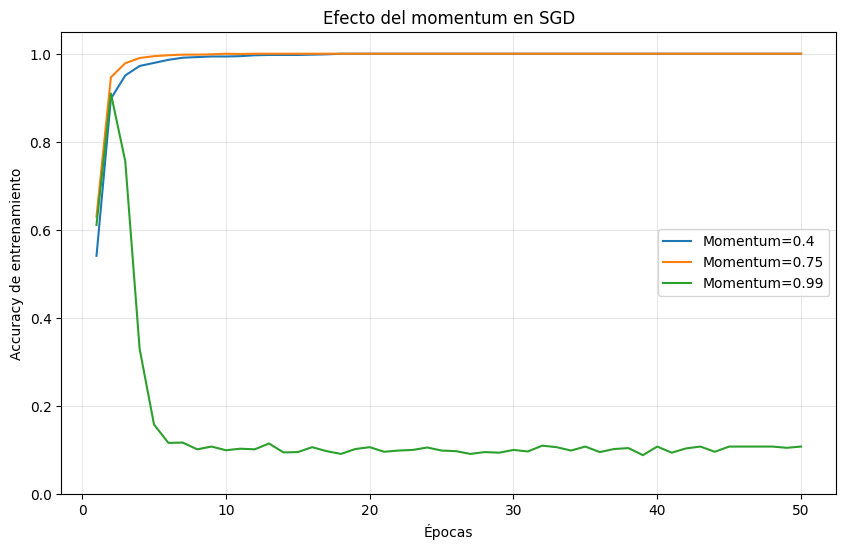

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
lr = 0.1 # learning rate
batch_size =  64  # Vector of mini-batch
momentum_beta1 = [0.4,0.75,0.99]   # AQUI SE DEFINE LOS MOMENTOS
adam_beta1 = 0.9
adam_beta2 = 0.999

# ---- Train Model with Each Learning Rate ----
history_acc_Mom = {}  # A SER LLENADO
for mom in momentum_beta1:

    tf.keras.utils.set_random_seed(42)

    print(f"Training with Momentum = {mom}...")

    optimizer_Momentum = tf.keras.optimizers.SGD(
        learning_rate=lr,
        momentum=mom
    )

    model_Mom = build_model(activation="relu")

    model_Mom.compile(
        optimizer=optimizer_Momentum,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_Mom = model_Mom.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=batch_size,
        verbose=0,
        validation_data=(X_test, y_test)
    )

    history_acc_Mom[f"Momentum={mom}"] = (
        history_Mom.history["accuracy"]
    )


# ---- Plot Accuracy Convergence ----
plt.figure(figsize=(10, 6))

for name, acc in history_acc_Mom.items():
    plt.plot(
        range(1, len(acc) + 1),
        acc,
        label=name
    )

plt.xlabel("Épocas")
plt.ylabel("Accuracy de entrenamiento")
plt.title("Efecto del momentum en SGD")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#4. Cambiar la Función de Activación en las capas ocultas del optimizador Adam: Graficar  Accuracy vs. Epochs

 # Prueba con relu, sigmoid, tanh

¿Qué función de activación produce mejores resultados de accuracy en la precisión final?

Livia: estos fueron mis resultados
relu: 100.0000%
sigmoid: 99.1649%
tanh: 100.0000%
Lo que parece un empate tecnico entre relu y tanh no es del todo correcto cuando en el grafico verificamos la cantidad de epocas que les tomo a cada modelo llegar a ese 100%.
tanh: alcanzó el 100 % en la época 37
relu: alcanzó el 100 % en la época 28
Ya con esta data se puede concluir que para este dataset con las condiciones dadas, relu y tanh son las mejores funciones de activacion en las capas ocultas en cuanto a accuracy, pero el relu es mas eficiente por que logra el 100% de accurac en 9 epocas menos que el tanh.


Training with Learning Rate = relu...
Training with Activation = relu...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Learning Rate = sigmoid...
Training with Activation = sigmoid...
Training with Learning Rate = tanh...
Training with Activation = tanh...


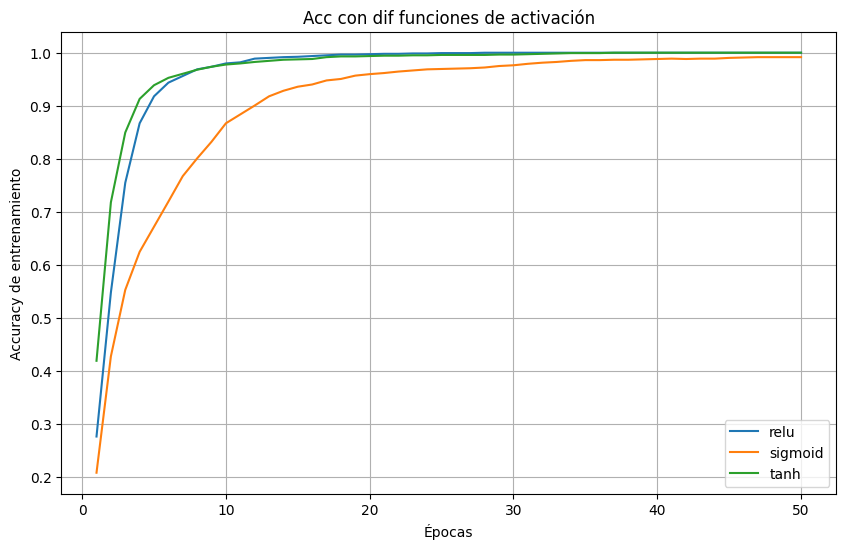

Accuracy final de entrenamiento:

relu: 100.0000%
sigmoid: 99.1649%
tanh: 100.0000%

Mejor(es) activación(es): relu, tanh
Mayor accuracy final: 100.0000%
relu: alcanzó el 100 % en la época 28
tanh: alcanzó el 100 % en la época 37

Llegó primero: relu, en la época 28.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
lr = 0.001 # learning rate
batch_size =  64  # mini-batch
momentum_beta1 = 0.9
adam_beta1 = 0.9
adam_beta2 = 0.999
activacion = ["relu", "sigmoid", "tanh"]    #FUNCIONES DE ACTIVACIÓN A SER PROBADAS
# ---- Train Model with Each Learning Rate ----
history_acc_Adam = {}

for ac in activacion:
    print(f"Training with Learning Rate = {ac}...")
     # Inserta su código aqui. Hint: se debe insertar los codigos de #1 hasta # 5 de la actividad 1  utilizando el optimizador Adam y reemplazando los parámetros correspondientes
    tf.keras.utils.set_random_seed(42)

    print(f"Training with Activation = {ac}...")

    optimizer_Adam = tf.keras.optimizers.Adam(
        learning_rate=lr,
        beta_1=adam_beta1,
        beta_2=adam_beta2
    )

    model_Adam = build_model(activation=ac)

    model_Adam.compile(
        optimizer=optimizer_Adam,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_Adam = model_Adam.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=batch_size,
        verbose=0,
        validation_data=(X_test, y_test)
    )

    history_acc_Adam[ac] = history_Adam.history["accuracy"]



# ---- Plot Accuracy Convergence ----
# Inserta el código desde   #1 Base hasta   #9 Base con las respectivas modificaciones de nombres de variables

plt.figure(figsize=(10, 6))                          #1 Base
for name, acc in history_acc_Adam.items():           #2 Base
    plt.plot(range(1, len(acc) + 1), acc, label=name) #3 Base

plt.xlabel("Épocas")                                #4 Base
plt.ylabel("Accuracy de entrenamiento")             #5 Base
plt.title("Acc con dif funciones de activación")    #6 Base
plt.legend()                                        #7 Base
plt.grid()                                          #8 Base
plt.show()                                          #9 Base


#Informacion adicional para el analisis
print("Accuracy final de entrenamiento:\n")

for ac, acc in history_acc_Adam.items():
    print(f"{ac}: {acc[-1]:.4%}")

mejor_accuracy = max(
    acc[-1] for acc in history_acc_Adam.values()
)

mejores_activaciones = [
    ac
    for ac, acc in history_acc_Adam.items()
    if np.isclose(acc[-1], mejor_accuracy, rtol=0, atol=1e-8)
]

print("\nMejor(es) activación(es):", ", ".join(mejores_activaciones))
print(f"Mayor accuracy final: {mejor_accuracy:.4%}")

#adicionando codigo para estblecer que modelo llega mas arpido al 100% de accuracy
primeras_epocas = {}

for activacion in ["relu", "tanh"]:
    accuracies = history_acc_Adam[activacion]

    for epoca, accuracy in enumerate(accuracies, start=1):
        if accuracy == 1.0:
            primeras_epocas[activacion] = epoca
            print(f"{activacion}: alcanzó el 100 % en la época {epoca}")
            break
    else:
        print(f"{activacion}: no alcanzó el 100 % en las épocas entrenadas")

# Comparar quién llegó primero
if primeras_epocas:
    primera = min(primeras_epocas.values())

    ganadoras = [
        nombre
        for nombre, epoca in primeras_epocas.items()
        if epoca == primera
    ]

    if len(ganadoras) > 1:
        print(f"\nEmpate: ambas llegaron al 100 % en la época {primera}.")
    else:
        print(f"\nLlegó primero: {ganadoras[0]}, en la época {primera}.")
else:
    print("\nNinguna alcanzó exactamente el 100 %.")

***OPCIONAL (TRABAJAR CON OTRO DATASET)***




Training with Gradient Descent (GD)...
Training with Stochastic GD (SGD)...
Training with Mini-Batch GD...
Training with Momentum GD...
Training with Adam...


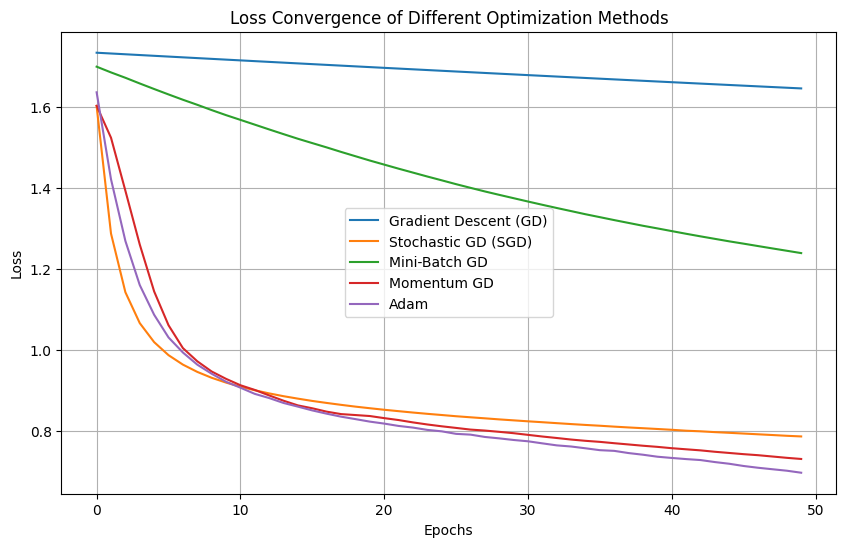

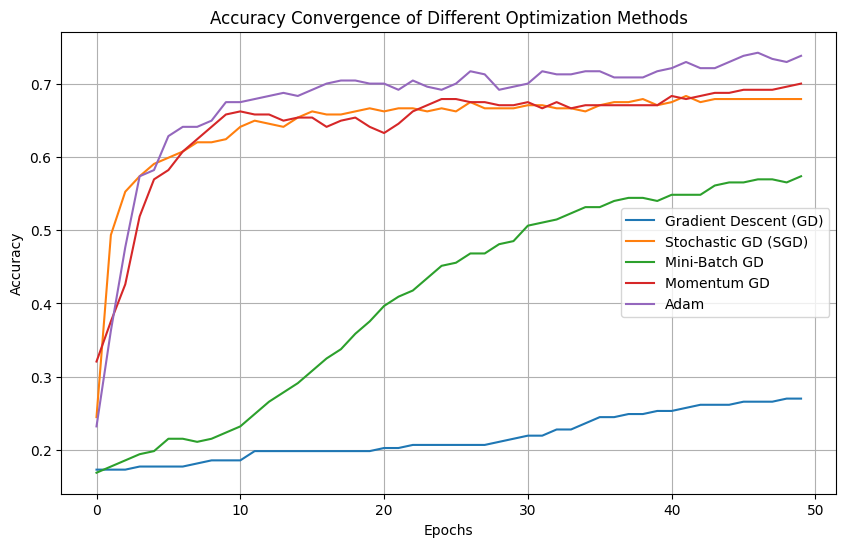

In [ ]:
# Instalar dependencias
!pip install -q ucimlrepo
# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
# 1) Cargar dataset UCI (generalizado)
# Cambia el ID del dataset si deseas otro
heart_disease = fetch_ucirepo(id=45)  # Ejemplo: Heart Disease
X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets     # Puede tener varias columnas

# Unir para limpiar de forma consistente
df = pd.concat([X_raw, y_raw], axis=1)

# Limpiar NaN e infinitos
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Detectar automáticamente la columna objetivo
target_col = y_raw.columns[0]
X = df.drop(columns=[target_col])
y = df[target_col].astype(int).squeeze()  # Serie 1D

# One-hot para categóricas
X = pd.get_dummies(X, drop_first=True)

# Dividir en train/test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarizar SOLO X
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2) Definir modelo (generalizado)
def build_model(X_train, y_train, activation="tanh"):
    """
    Construye automáticamente el modelo ajustando:
    - Input shape (según X_train)
    - Número de clases (según y_train)
    - Tipo de salida (sigmoid o softmax)
    - Función de pérdida (binary o categorical)
    """
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    inputs = tf.keras.Input(shape=(n_features,))
    x = tf.keras.layers.Dense(64, activation=activation)(inputs)
    x = tf.keras.layers.Dense(32, activation=activation)(x)

    if n_classes == 2:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
        loss = "binary_crossentropy"
    else:
        outputs = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
        loss = tf.keras.losses.SparseCategoricalCrossentropy()

    model = tf.keras.Model(inputs, outputs)
    return model, loss

# 3) Hiperparámetros y optimizadores
learning_rate = 0.001
momentum_beta1 = 0.98
adam_beta1 = 0.9
adam_beta2 = 0.999

optimizers = {
    "Gradient Descent (GD)": tf.keras.optimizers.SGD(learning_rate=learning_rate),
    "Stochastic GD (SGD)": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0),
    "Mini-Batch GD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0),
    "Momentum GD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum_beta1),
    "Adam": tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=adam_beta1, beta_2=adam_beta2),
}

batch_sizes = {
    "Gradient Descent (GD)": X_train.shape[0],  # usa todas las muestras
    "Stochastic GD (SGD)": 1,                   # 1 muestra por iteración
    "Mini-Batch SGD": 32,                        # minibatches de 32
    "Momentum GD": 32,                          # igual que mini-batch
    "Adam": 32,                                 # adam usa mini-batch
}

# 4) Entrenar con cada optimizador
history_loss = {}
history_acc = {}

for name, optimizer in optimizers.items():
    print(f"Training with {name}...")
    model, loss_fn = build_model(X_train, y_train, activation="tanh")
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=batch_sizes[name],
        verbose=0,
        validation_data=(X_test, y_test)
    )
    history_loss[name] = history.history["loss"]
    history_acc[name] = history.history["accuracy"]

# 5) Gráficos de convergencia
plt.figure(figsize=(10, 6))
for name, loss in history_loss.items():
    plt.plot(loss, label=name)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Convergence of Different Optimization Methods")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
for name, acc in history_acc.items():
    plt.plot(acc, label=name)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Convergence of Different Optimization Methods")
plt.legend()
plt.grid()
plt.show()



# 5. Comparación estadística de dos modelos

En las Actividades 1 a 4 se comparo configuraciones **mirando curvas**. Ahora vamos a comparar
**dos modelos distintos** con un criterio estadístico, sobre el mismo dataset de dígitos.

```text
Modelo A: Red neuronal (MLP)          -> el enfoque del laboratorio
Modelo B: Random Forest               -> familia completamente distinta
```

Ambos se evalúan sobre **los mismos 10 folds**. Por eso los resultados están *pareados*:

```text
Fold 1  ->  A y B usan exactamente el mismo conjunto de prueba
Fold 2  ->  A y B usan exactamente el mismo conjunto de prueba
...
```

## Lo visto en Clases

| Herramienta | Qué responde |
|---|---|
| **t-test pareado** | ¿La diferencia promedio es distinta de cero? (asume normalidad) |
| **Wilcoxon** | Lo mismo, sin asumir normalidad (usa rangos) |
| **Cohen's d** | ¿Qué tan **grande** es la diferencia? (el p-valor no lo dice) |
| **Bootstrap IC 95%** | ¿Entre qué valores está la diferencia real? |

Los dos primeros dan una decisión binaria. Los dos últimos dicen **cuánto**, que suele
importar más. Un p pequeño con un efecto minúsculo no sirve para nada en la práctica.

## Qué completar

Solo **tres líneas** (t-test, Wilcoxon y Cohen's d), las hipótesis y la conclusión.
El bootstrap y las diferencias pareadas ya vienen resueltos.

## Preguntas

1. ¿Coinciden el t-test y el Wilcoxon? Si no, ¿a cuál le crees?
Livia: si coinciden ambos no rechazan a H0 que esablece que ambos modelos funcionan igual. En la practica esta evaluaconpodria ampliarse aconsiderar variables como costo computacional, la estabilidad, cmplejidad,ect.

2. El intervalo bootstrap, ¿incluye el cero? ¿Es coherente con el p-valor?
Livia: El intervalo de Bootstrap incluyo el cero. Si es coherente con el p-valor, noahya una diferencia marcada entre modelos.

3. Según Cohen's d, ¿la diferencia es pequeña (0.2), mediana (0.5) o grande (0.8)?
Livia:el valore redondeado de Cohen's d fue 0.4 entre pequena y mediana.
   ¿Le recomendarías a alguien cambiar de modelo con base en esto? No no recoemndaria cambiar un modelo por otro, segun los test Radom Forest tinee una ligera ventaja pero las distas evaluaciones no rechazaron H0.


In [18]:
# ACTIVIDAD 5 — Comparación estadística de dos modelos
import numpy as np, warnings
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel, wilcoxon
warnings.filterwarnings("ignore")

X, y = load_digits(return_X_y=True)     # mismo dataset de las actvidades anteriores

# ---- Los dos modelos a comparar ----
modelo_A = make_pipeline(               # escalado DENTRO del pipeline (sin fuga)
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=0)
)
modelo_B = RandomForestClassifier(n_estimators=200, random_state=0)

# ---- Mismos folds para ambos -> comparación pareada ----
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

sc_A, sc_B = [], []                     # aqui se guarda 1 accuracy por fold
for tr, te in cv.split(X, y):
    modelo_A.fit(X[tr], y[tr]); sc_A.append(accuracy_score(y[te], modelo_A.predict(X[te])))
    modelo_B.fit(X[tr], y[tr]); sc_B.append(accuracy_score(y[te], modelo_B.predict(X[te])))

sc_A = np.array(sc_A)   # 10 accuracies del MLP           -> sc_A[i] = accuracy en el fold i
sc_B = np.array(sc_B)   # 10 accuracies del Random Forest -> sc_B[i] = accuracy en el fold i

# ---- Diferencias pareadas: d_i = acc_RandomForest(fold i) - acc_MLP(fold i) ----
d = sc_B - sc_A         # resta fold contra fold: d[0]=sc_B[0]-sc_A[0], d[1]=sc_B[1]-sc_A[1], ...

print(f"MLP           : {sc_A.mean():.4f} +/- {sc_A.std(ddof=1):.4f}")
print(f"Random Forest : {sc_B.mean():.4f} +/- {sc_B.std(ddof=1):.4f}")
print(f"\nsc_A (MLP por fold): {np.round(sc_A, 4)}")
print(f"sc_B (RF  por fold): {np.round(sc_B, 4)}")
print(f"d = sc_B - sc_A    : {np.round(d, 4)}")
print(f"\nMedia de las diferencias: {d.mean():.4f}")
print("d_i > 0 -> gano Random Forest en ese fold | d_i < 0 -> gano el MLP")

#Livia Completando claculos para el anailisis
# ---- Prueba t de Student pareada ----

n = len(d)
media_d = d.mean()
desviacion_d = d.std(ddof=1)
error_estandar = desviacion_d / np.sqrt(n)
grados_libertad = n - 1

# SciPy calcula el estadístico t y el p-value bilateral.
# Orden B, A para que el signo coincida con d = sc_B - sc_A.
t_stat, p_value = ttest_rel(sc_B, sc_A)

print(f"Número de pares: {n}")
print(f"Media de las diferencias: {media_d:.6f}")
print(f"Desviación estándar de las diferencias: {desviacion_d:.6f}")
print(f"Error estándar de la media: {error_estandar:.6f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"Estadístico t: {t_stat:.6f}")
print(f"p-value bilateral: {p_value:.6g}")
#-------------------------------------------------------------------------

#Livia
# ---- Prueba de Wilcoxon de rangos con signo (pareada) ----

from scipy.stats import wilcoxon

# Diferencias RF - MLP.
# Redondear evita que errores numéricos alteren los rangos.
d_w = np.round(sc_B - sc_A, decimals=12)

alpha = 0.05

if np.all(d_w == 0):
    print("Todas las diferencias son cero.")
    print("No hay diferencias observadas para evaluar con Wilcoxon.")
else:
    resultado = wilcoxon(
        d_w,
        alternative="two-sided",
        zero_method="wilcox",
        method="auto"
    )
    print(f"Resultados Wilcoxon")
    print(f"Pares totales: {len(d_w)}")
    print(f"Pares con diferencia no nula: {np.count_nonzero(d_w)}")
    print(f"Estadístico W: {resultado.statistic:.6f}")
    print(f"p-value bilateral: {resultado.pvalue:.6g}")

    if resultado.pvalue < alpha:
        print("\nSe rechaza H0 al nivel de significancia del 5 %.")
        print("Hay evidencia de una diferencia entre los modelos.")
    else:
        print("\nNo se rechaza H0 al nivel de significancia del 5 %.")
        print("No hay evidencia suficiente de una diferencia entre los modelos.")


#------------------------------------------------------------------------------
alpha = 0.05

if not np.isfinite(p_value):
    print("\nLa prueba no produjo un p-value válido; revisa las diferencias.")
elif p_value < alpha:
    print("\nSe rechaza H0 al nivel de significancia del 5 %.")
    print("La prueba indica una diferencia estadísticamente significativa.")
else:
    print("\nNo se rechaza H0 al nivel de significancia del 5 %.")
    print("La prueba no aporta evidencia suficiente de una diferencia.")

#Livia
# ---- Cohen's d pareado (d_z) ----
print("Resultados Cohen")


media_d = np.mean(d)
std_d = np.std(d, ddof=1)

if std_d == 0:
    print("No se puede calcular d_z: la desviación estándar es cero.")
else:
    cohen_d = media_d / std_d

    print(f"Media de las diferencias: {media_d:.6f}")
    print(f"Desviación estándar de las diferencias: {std_d:.6f}")
    print(f"Cohen's d pareado (d_z): {cohen_d:.4f}")

# ---- Bootstrap: IC 95% para la media de las diferencias (YA RESUELTO) ----
rng = np.random.default_rng(123)
boot = np.array([rng.choice(d, size=len(d), replace=True).mean() for _ in range(10000)])
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
print(f"\nIC 95% (bootstrap) de la diferencia media: [{ci_low:.4f}, {ci_high:.4f}]")

# ------------------------------------------------------------
# TODO 1 — Hipótesis sobre las diferencias d_i (escribir, no es código)
#   H0: MLP = Random Forest No haydiferencia entre los  modelos
#   H1: MLP <> Random Forest, si hay diferencia entre los modelos
# ------------------------------------------------------------

# ------------------------------------------------------------
# TODO 2 — t-test pareado sobre sc_B y sc_A
#  Resultados: d = sc_B - sc_A    : [ 0.0111  0.0167 -0.0111 -0.0056 -0.0111  0.0111  0.0222  0.0056  0.00560.]
#donde:
#d_i = acc_RandomForest(fold i) - acc_MLP(fold i)
# Randomforest le gana 6 veces a MLP evalundo los resultados de las diferencias
# ------------------------------------------------------------
# t, p_t = ...
#en laprueba t studet pareada se calculala media de las difreencias y la desviacion esatndar delas diferencias para un n de 10 obteneindo:
# t=1.239360 y >=  0.05  si bien esta por encima del nivel de significancia, es ligeramente por encima por lo tanto no es una evaluacion concluyente. No se rechaza H0.
#veamos con las otras puebas.
# ------------------------------------------------------------
# TODO 3 — Wilcoxon sobre d
# ------------------------------------------------------------
# w, p_w = ...
#El resultado fue W = 12 y p = 0.2422. Como p > 0.05, no se rechaza la hipótesis nula H0.
#Aunque Random Forest obtuvo una exactitud media ligeramente mayor, la prueba no detectó una diferencia significativa.
# ------------------------------------------------------------
# TODO 4 — Cohen's d pareado:  media(d) / desviacion estandar(d)
#          (usar ddof=1)
# ------------------------------------------------------------
# cohen_d = 0.3919
#Cohen’s d pareado fue de 0.3919,que segun la tabla la diferencia es pequena.
#
# ------------------------------------------------------------
# TODO 5 — Decision con alpha = 0.05 (descomentar al completar)
# ------------------------------------------------------------
alpha = 0.05
#t=1.239360 y >=  0.05  si bien esta por encima del nivel de significancia, es ligeramente por encima por lo tanto no es una evaluacion concluyente. No se rechaza H0.
#El resultado fue W = 12 y p = 0.2422. Como p >= 0.05, no se rechaza la hipótesis nula
#Cohen’s d pareado fue de 0.3919>=0.05 que segun la tabla la diferencia es pequena. No rechaza H0

# TODO 6 — Escribe tu conclusión en 1-2 frases.
#  el IC bootstrap C 95% (bootstrap) de la diferencia media: [-0.0022, 0.0111]  es un itervalo que tiene mas valores del lado positivo pero al incluir el cero en el intervalo La diferencia no es consistente.
#Conclusion Final: No se rechaza la H0 que dice que no hay diferencia entre Radom Forest y MLP.  Aunque Ramndom Forest tiene ligera ventajas en los dos priemros test en general no siento que sea concluyente esa poneracion hacia random Forest.

MLP           : 0.9744 +/- 0.0088
Random Forest : 0.9789 +/- 0.0069

sc_A (MLP por fold): [0.9722 0.9667 0.9833 0.9833 0.9833 0.9667 0.9667 0.9777 0.9609 0.9832]
sc_B (RF  por fold): [0.9833 0.9833 0.9722 0.9778 0.9722 0.9778 0.9889 0.9832 0.9665 0.9832]
d = sc_B - sc_A    : [ 0.0111  0.0167 -0.0111 -0.0056 -0.0111  0.0111  0.0222  0.0056  0.0056
  0.    ]

Media de las diferencias: 0.0045
d_i > 0 -> gano Random Forest en ese fold | d_i < 0 -> gano el MLP
Número de pares: 10
Media de las diferencias: 0.004451
Desviación estándar de las diferencias: 0.011356
Error estándar de la media: 0.003591
Grados de libertad: 9
Estadístico t: 1.239360
p-value bilateral: 0.246556
Resultados Wilcoxon
Pares totales: 10
Pares con diferencia no nula: 9
Estadístico W: 12.000000
p-value bilateral: 0.242188

No se rechaza H0 al nivel de significancia del 5 %.
No hay evidencia suficiente de una diferencia entre los modelos.

No se rechaza H0 al nivel de significancia del 5 %.
La prueba no aporta evidencia s